In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [2]:
import os
cwd= os.getcwd()
path = os.path.join(cwd,'data')

In [5]:
def get_train_set():
    fp = os.path.join(path, 'titanic_train.csv')
    df_train = pd.read_csv(fp)
    return df_train

df_train = get_train_set()
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
def get_test_set():
    fp = os.path.join(path, 'titanic_test.csv')
    df_test = pd.read_csv(fp)
    return df_test 

df_test = get_test_set()
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
def clean_blank_target(df):
    print ('cleaning blank target.')
    print ('Len before cleaning= {:,}'.format(len(df)))
    df = df.dropna(subset=['Survived'])
    print ('Len after cleaning= {:,}'.format(len(df)))
    return df
    
df_train = clean_blank_target(df_train)

cleaning blank target.
Len before cleaning= 891
Len after cleaning= 891


In [8]:
def get_X_train_test(df_train, df_test): 
    print ('Extracting features.')
    
    cols_to_keep= [
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked']
    
    X_train = df_train[cols_to_keep]
    X_test = df_test[cols_to_keep]
    return X_train, X_test, cols_to_keep

X_train, X_test, features  = get_X_train_test(df_train, df_test)
y_train = df_train['Survived']
X_train.shape

Extracting features.


(891, 7)

In [9]:
X_train.dtypes

Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

In [10]:
columns_to_encode = ['Sex', 'Embarked']

In [11]:
def label_encoder(X_train, X_test):    
    print ('label encoding.')
    X_train = X_train.copy() 
    X_test = X_test.copy()

    for col in columns_to_encode:
        le = LabelEncoder().fit(X_train[col].astype(str))
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
    return X_train,X_test

X_train, X_test= label_encoder(X_train,X_test)
X_train.dtypes

label encoding.


Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

In [12]:
X_train.isna().any()

Pclass      False
Sex         False
Age          True
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

In [13]:
def fill_na(df):
    print ('filling NaN...')
    for col in list(df):
        if df[col].isna().any():
            df[col]= df[col].fillna(0)

fill_na(X_train)
fill_na(X_test)
X_train.isna().any().any(), X_test.isna().any().any()

filling NaN...
filling NaN...


(np.False_, np.False_)

In [14]:
def normalize(X_train, X_test):
    print ('normalizing.')
    scaler= MinMaxScaler()
    X_train_scaled= scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled 

X_train_scaled, X_test_scaled  = normalize(X_train, X_test)
type(X_train_scaled)

normalizing.


numpy.ndarray

In [15]:
def run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train, y_test= None):
    print ('Running GridSearchCV.')
    grid_clf = GridSearchCV(clf, param_grid=grid_values,scoring='f1')
    grid_clf.fit(X_train_scaled, y_train)
    print('Grid best parameter (max f1 ): ', grid_clf.best_params_) 
    print('Grid best score (f1): ', grid_clf.best_score_) 

    if not y_test is None:
        test_score= grid_clf.score(X_test_scaled, y_test)
        print("test f1= {}".format(test_score))

def run_all_classifiers(X_train_scaled, X_test_scaled, y_train, y_test=None, list_classifiers= None):
    if list_classifiers is None or 'LogisticRegression' in list_classifiers:
        print ('\nLogisticRegression.')
        clf = LogisticRegression(max_iter=10000)
        grid_values = {'C': [0.005, 0.01,0.1, 1, 100, 10000, 100000]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled,  y_train,  y_test= y_test)

    if list_classifiers is None or 'DecisionTreeClassifier' in list_classifiers:
        print ('\nDecisionTreeClassifier')
        clf = DecisionTreeClassifier()       
        grid_values = {'max_depth': [2,5,7, 20, 50]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'RandomForestClassifier' in list_classifiers:
        print ('\nRandomForestClassifier.')
        clf = RandomForestClassifier()       
        grid_values = {'n_estimators': [20,50]} 
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'SVC_poly' in list_classifiers:
        print ('\nSVC_poly')
        clf = SVC(kernel='poly')           
        grid_values = {'C': [0.01]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'SVC_rbf' in list_classifiers:
        print ('\nSVC_rbf')
        clf = SVC(kernel='rbf')
        grid_values = {'C': [0.005, 0.01]}
        run_GridSearchCV(clf,grid_values, X_train_scaled, X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'NB' in list_classifiers:
        print ('\nNB')
        clf =  GaussianNB().fit(X_train_scaled, y_train)
        train_f1 = f1_score(y_train, clf.predict(X_train_scaled))
        print("train set f1= {}".format(train_f1))
        if not y_test is None:
            test_f1 = f1_score(y_test, clf.predict(X_test_scaled))
            print("train set f1= {}".format(test_f1))

    if list_classifiers is None or 'GradientBoostingClassifier' in list_classifiers:
        print ('\nGradientBoostingClassifier.')
        clf = GradientBoostingClassifier()      
        grid_values = {'max_depth': [3,5,7]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'MLP' in list_classifiers:
        print ('\nMLP.')
        clf = MLPClassifier(hidden_layer_sizes = [50]) 
        grid_values = {'alpha' : [0.001, 0.01, 0.1, 1, 10]}
        run_GridSearchCV(clf,grid_values, X_train_scaled,X_test_scaled, y_train,  y_test= y_test)   

    if list_classifiers is None or 'xgboost' in list_classifiers:
        print ('\nxgboost.')
        clf = XGBClassifier().fit(X_train_scaled, y_train)
        y_predicted = clf.predict(X_test_scaled)
        print ('f1_score  = {:.2}'.format(f1_score(y_test, y_predicted)))

In [16]:
def apply_preprocessing(df_train, df_test):
    df_train = df_train.dropna(subset=['Survived'])
    y_train = df_train['Survived']

    y_test = None
    if 'Survived' in df_test.columns:
        y_test = df_test['Survived']

    cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

    X_train = df_train[cols]
    X_test = df_test[cols]

    X_train, X_test = label_encoder(X_train, X_test)

    fill_na(X_train)
    fill_na(X_test)

    X_train_scaled, X_test_scaled = normalize(X_train, X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, cols

In [17]:
df= get_train_set ()
df_train, df_test = train_test_split(df, random_state= 0)
X_train_scaled, X_test_scaled, y_train, y_test, features = apply_preprocessing(df_train, df_test)

print ('X_train_scaled shape= {}\nX_test_scaled shape= {}'.format(X_train_scaled.shape, X_test_scaled.shape))
print ('y_train set shape= {}\ny_test set shape= {}'.format(y_train.shape, y_test.shape))

label encoding.
filling NaN...
filling NaN...
normalizing.
X_train_scaled shape= (668, 7)
X_test_scaled shape= (223, 7)
y_train set shape= (668,)
y_test set shape= (223,)


In [18]:
list_classifiers= [
    'LogisticRegression',
    'DecisionTreeClassifier',
    'RandomForestClassifier',
    'NB',
    'GradientBoostingClassifier', 
    'xgboost'
]
run_all_classifiers(X_train_scaled, X_test_scaled, y_train, y_test, list_classifiers= list_classifiers)


LogisticRegression.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'C': 10000}
Grid best score (f1):  0.7139575052408803
test f1= 0.7368421052631579

DecisionTreeClassifier
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 7}
Grid best score (f1):  0.7240790288729413
test f1= 0.7421383647798742

RandomForestClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'n_estimators': 50}
Grid best score (f1):  0.7272848034550161
test f1= 0.7612903225806451

NB
train set f1= 0.7279843444227005
train set f1= 0.7262569832402235

GradientBoostingClassifier.
Running GridSearchCV.
Grid best parameter (max f1 ):  {'max_depth': 5}
Grid best score (f1):  0.7376664951441381
test f1= 0.7530864197530864

xgboost.
f1_score  = 0.81


In [19]:
df_train= get_train_set ()
df_test= get_test_set()

X_train_scaled_1, X_test_scaled_1, y_train_1, y_test_1, features = apply_preprocessing(df_train, df_test)

print ('X_train_scaled shape= {}\nX_test_scaled shape= {}'.format(X_train_scaled_1.shape, X_test_scaled_1.shape))
print ('y_train set shape= {}'.format(y_train_1.shape))
print ('y_test type = {}'.format(type(y_test_1)))

label encoding.
filling NaN...
filling NaN...
normalizing.
X_train_scaled shape= (891, 7)
X_test_scaled shape= (418, 7)
y_train set shape= (891,)
y_test type = <class 'NoneType'>


In [20]:
clf = RandomForestClassifier(n_estimators= 20)       

from sklearn.model_selection import cross_val_score  
f1_train = cross_val_score(clf, X_train_scaled_1, y_train_1, cv=5, scoring='f1')
print (f1_train)
            
clf.fit(X_train_scaled_1, y_train_1)
y_predict= clf.predict(X_test_scaled_1)

np.mean(y_predict)

[0.71014493 0.70676692 0.78787879 0.67768595 0.75714286]


np.float64(0.35406698564593303)

In [21]:
values, counts = np.unique(y_predict, return_counts=True)
dict(zip(values, counts))

{np.int64(0): np.int64(270), np.int64(1): np.int64(148)}

In [22]:
clf = RandomForestClassifier(n_estimators= 20)       

from sklearn.model_selection import cross_val_score 
f1_train = cross_val_score(clf, X_train_scaled_1, y_train_1, cv=5, scoring='f1')
print (f1_train)
            
clf.fit(X_train_scaled_1, y_train_1)
y_predict= clf.predict_proba(X_test_scaled_1)

np.mean(y_predict)

[0.71212121 0.72727273 0.76691729 0.69354839 0.7761194 ]


np.float64(0.5)

In [23]:
values, counts = np.unique(y_predict, return_counts=True)
dict(zip(values, counts))

{np.float64(0.0): np.int64(105),
 np.float64(0.01388888888888889): np.int64(1),
 np.float64(0.05): np.int64(57),
 np.float64(0.06): np.int64(1),
 np.float64(0.06666666666666667): np.int64(1),
 np.float64(0.06999999999999999): np.int64(1),
 np.float64(0.07345238095238096): np.int64(1),
 np.float64(0.07884615384615384): np.int64(1),
 np.float64(0.08891053391053391): np.int64(5),
 np.float64(0.09003843378843376): np.int64(9),
 np.float64(0.09166666666666666): np.int64(1),
 np.float64(0.1): np.int64(38),
 np.float64(0.10833333333333332): np.int64(1),
 np.float64(0.11000000000000001): np.int64(1),
 np.float64(0.11666666666666665): np.int64(2),
 np.float64(0.13999999999999999): np.int64(1),
 np.float64(0.14166666666666666): np.int64(1),
 np.float64(0.15): np.int64(33),
 np.float64(0.16): np.int64(1),
 np.float64(0.16666666666666669): np.int64(1),
 np.float64(0.175): np.int64(1),
 np.float64(0.18291666666666667): np.int64(1),
 np.float64(0.2): np.int64(39),
 np.float64(0.20914682539682544): n

In [24]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

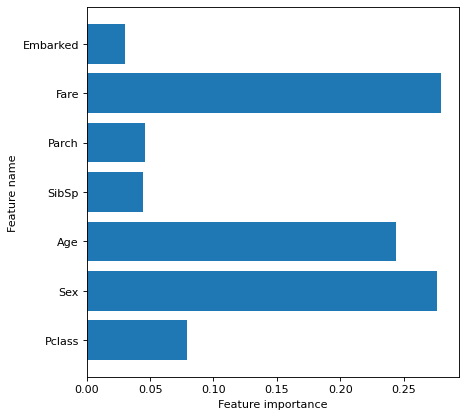

In [25]:
plot_feature_importances(clf, features)